In [1]:
import pandas as pd
from postprocessinglib.evaluation import data, visuals
import tempfile
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib.dates as mdates
import os
import contextlib
import io
import numpy as np
from cmap import Colormap
import datetime as dt

In [2]:
def add_series(predf, path, station, stats, start, end, historic, iteration): #CHECK THAT THIS IS USING THE CORRECT DATA FOR HISTORIC

    # Because NHS Postprocessing requires a csv input, we export the subset to .csv through a temporary file
    with tempfile.NamedTemporaryFile(mode = 'w+', suffix = 'csv', delete = False) as tmp:
    
        predf.to_csv(tmp.name, index = False)

        # Suppress printed outputs from data.generate_dataframes for compatibility
        with contextlib.redirect_stdout(io.StringIO()):

            # Long term aggregation of the temporary subset file for each statistic
            dfs = data.generate_dataframes(csv_fpaths = tmp.name, warm_up = 366, start_date = start, end_date = end)
            
            for stat in stats: 

                if historic in path and iteration == 1: dfs['LONG_TERM_' + stat.upper()] = data.long_term_seasonal(df = dfs['DF_OBSERVED'], method = stat)                
                else: dfs['LONG_TERM_' + stat.upper()] = data.long_term_seasonal(df = dfs['DF_SIMULATED'], method = stat)

    # Stats for the line and ribbon are predefined, and here applied to a dictionary. map() adjusts the name for compatibility
    series = dict(zip(stats, map(lambda stat: dfs[f'LONG_TERM_{stat.upper()}'].iloc[:, 0], stats)))
    return series

In [3]:
def plot_series(run, period, series, config, ax, index, colour):

    # Setting x-axis and plotting the line
    days = series[config['Middle']].index.values

    obs = 'Observations (1981–2014)'
    series[config['Middle']].plot(ax = ax, label = period, color = 'k' if period == obs else colour,  
                                  linewidth = 1.5 if period == obs else 1.5, alpha = 0.6 if period == obs else None)

    # Plotting the ribbon
    ax.fill_between(days, series[config['Lower']], series[config['Upper']], 
                    color = 'k' if period == obs else colour, alpha = 0.2 if period == obs else 0.3)

    # Customize title and axis labels
    run_title = run[:4] + '-' + run[4] + '.' + run[5:]
    ax.set_title(run_title)

    # Configuring date axis
    ax.set_xlim(0, 366)
    months = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    labels = ['Jan', '', 'Mar', '', 'May', '', 'Jul', '', 'Sep', '', 'Nov', '']
    ax.set_xticks(months)
    
    if index >= 2: ax.set_xticklabels(labels)  
    else: ax.set_xticklabels('')
    ax.set_xlabel('')

    # Configuring discharge axis
    if index % 2 == 0: ax.set_ylabel('Discharge ($\mathdefault{m^3/s}$)')
    else: ax.set_ylabel(''); ax.set_yticklabels('')
    
    if index == 1: ax.legend(fontsize = 'small')
    ax.grid(alpha = 0.5)

In [4]:
def generate_plot(station, run_hist = True, run_ssps = True, plot_ssps = True):

    config = {'Lower':  'q10', 
              'Middle': 'median', 
              'Upper':  'q90'}
    stats = list(config.values())
    folder, pathways = os.path.join(os.path.dirname(os.getcwd()), 'CanESM5'), {}


    
    # Defining scenarios and pre-loading historical files
    runs = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
    historic = 'historic'
    hist_file = [item for item in os.listdir(folder) if historic in item][0]
    hist_path = os.path.join(folder, hist_file)
    use_cols = ['YEAR', 'JDAY', f'QOMEAS_{station}', f'QOSIM_{station}']
    hist_df = pd.read_csv(hist_path, usecols = use_cols); hist_df = hist_df[use_cols]   



    # For each file in folder, collect and preprocess data    
    for run in runs:

        # Check for scenario files in the folder
        file = [item for item in os.listdir(folder) if run in item][0]
        full_path = os.path.join(folder, file)
        print(f'({runs.index(run) + 1}/4) Processing station {station} in {os.path.basename(full_path)}' + ' ' * 20, end = '\r')

        # Pre-reading each scenario file
        run_df = pd.read_csv(full_path, usecols = use_cols); run_df = run_df[use_cols]
        
        # Series collects lines for historical, mid-century, and end of century
        predfs = [hist_df] * 2 + [run_df] * 2
        paths = [hist_path] * 2 + [full_path] * 2
        starts = ['1981-10-01', '1981-10-01', '2026-01-01', '2071-01-01']
        ends =   ['2014-12-31', '2014-12-31', '2055-12-31', '2100-12-31']
        iterations = list(range(1, 5))
        
        series = [add_series(predf, path, station, stats, start, end, historic, iteration) for \
                  predf, path, start, end, iteration in zip(predfs, paths, starts, ends, iterations)]
        
        periods = ['Observations (1981–2014)', 
                   'Pseudohistorical (1981–2014)', 
                   'Mid-Century (2026–2055)', 
                   'Late-Century (2071–2100)']     
        pathways[run] = dict(zip(periods, series))

    

    metadata = pd.read_csv('station_metadata.csv', usecols = ['Station Number', 'Station Name'])
    name = str(metadata[metadata['Station Number'] == station]['Station Name'].iloc[0])

    matplotlib.style.use('classic')
    fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))
    fig.subplots_adjust(wspace = 0.05, hspace = 0.105)
    axes = list(axes.flatten())

    # Adjust the starting point for the colourmap
    colour_id = 4

    cmap = Colormap('okabeito:okabeito')  # case insensitive
    colours = list(cmap(np.linspace(0, 1, 8)))[colour_id - 1:]

    # Plot the individual lines and ribbons
    for run, ax in zip(runs, axes):

        entry = pathways[run]
        plots = [plot_series(run, period, entry[period], config, ax, axes.index(ax), colour) for period, colour in zip(periods, colours)]

    plt.suptitle(f'Long-Term Aggregation of Streamflow at {name} ({station})', fontsize = 14)
    plt.savefig(os.path.join(folder, f'LTA_{station}_{colour_id}.png'))

(4/4) Processing station 05BB001 in MESH_output_streamflow_SSP585.csv                    

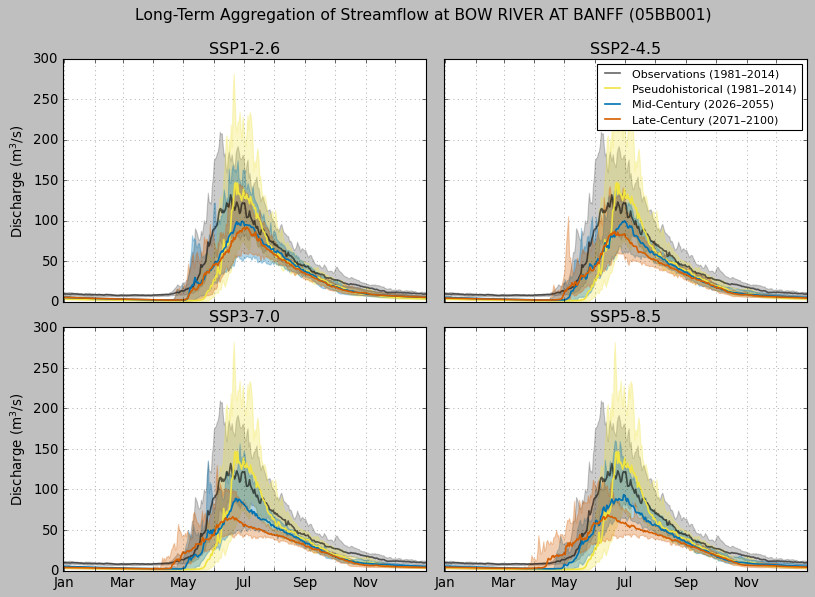

In [5]:
if __name__ == '__main__':

    generate_plot('05BB001')
    # plots = ['05BB001', '01AK010', '05AE027', '05AD007', '03KC004', '07OB001', '02GB001', '11AA031', '10LC017']
    # dummy = [generate_plot(plot) for plot in plots]